# **1. Dataset and Preprocessing**

In [1]:
# Install required libraries
!pip install -q torch torchvision pandas numpy matplotlib seaborn scikit-learn kagglehub

# Import base modules
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import kagglehub

# Check if GPU is enabled
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Download & Prepare the MNIST Dataset

In [2]:
# Create outputs directory for saving figures and model
os.makedirs("outputs", exist_ok=True)

# 1. Download Kaggle Dataset
dataset_path = Path(kagglehub.dataset_download("oddrationale/mnist-in-csv"))
print("Dataset downloaded to:", dataset_path)

# Define Class Names (0 to 9)
CLASS_NAMES = [str(i) for i in range(10)]

# 2. Data Loader Function
def load_mnist_csv(csv_name):
    file_path = dataset_path / csv_name
    df = pd.read_csv(file_path)

    # Extract labels and pixels
    y = df['label'].astype('int64')
    X = df.drop(columns=['label']).to_numpy(dtype=np.float32)

    # Normalize pixels to range [0.0, 1.0]
    X = X / 255.0
    return X, y

# Load Train and Test split
X_train, y_train = load_mnist_csv("mnist_train.csv")
X_test, y_test = load_mnist_csv("mnist_test.csv")

print("\n--- DATASET DETAILS ---")
print(f"X_train shape: {X_train.shape} (60,000 images, 784 flattened pixels)")
print(f"X_test shape : {X_test.shape} (10,000 images, 784 flattened pixels)")
print(f"Pixel min: {X_train.min()}, Pixel max: {X_train.max()}")

Using Colab cache for faster access to the 'mnist-in-csv' dataset.
Dataset downloaded to: /kaggle/input/mnist-in-csv

--- DATASET DETAILS ---
X_train shape: (60000, 784) (60,000 images, 784 flattened pixels)
X_test shape : (10000, 784) (10,000 images, 784 flattened pixels)
Pixel min: 0.0, Pixel max: 1.0


# **2. Model and Training**

Visualize Labeled Digit Samples (0–9)

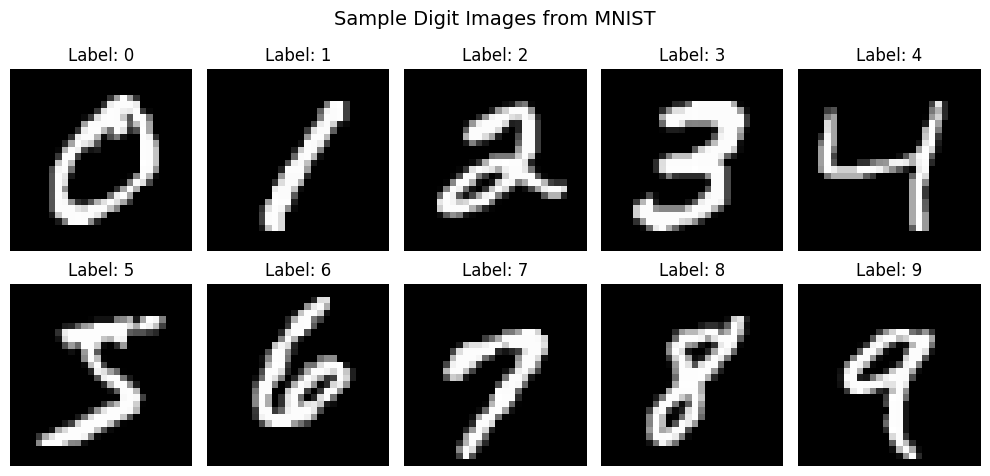

In [3]:
found_digits = {}
for i in range(len(X_train)):
    label = y_train.iloc[i]
    if label not in found_digits:
        found_digits[label] = X_train[i].reshape(28, 28)
    if len(found_digits) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for digit in range(10):
    row, col = divmod(digit, 5)
    ax = axes[row, col]
    ax.imshow(found_digits[digit], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")

plt.suptitle("Sample Digit Images from MNIST", fontsize=14)
plt.tight_layout()
plt.savefig("outputs/sample_digits.png", dpi=150)
plt.show()

Define Model Architecture & Hyperparameters


In [4]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Hyperparameters
torch.manual_seed(42)
BATCH_SIZE = 64
LEARNING_RATE = 0.001
EPOCHS = 20

# Convert NumPy arrays to PyTorch Tensors
train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train.values, dtype=torch.long))
test_ds = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test.values, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Multiclass Logistic Regression Model
class MNISTLogisticRegression(nn.Module):
    def __init__(self, input_dim=784, num_classes=10):
        super().__init__()
        self.linear = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        return self.linear(x)

model = MNISTLogisticRegression(784, 10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=0.0001)

print(model)

MNISTLogisticRegression(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


# **3. Evaluation and Predictions**

Train Model & Plot Loss Curve


Starting Training...
Epoch [01/20] Loss: 0.5401
Epoch [02/20] Loss: 0.3245
Epoch [03/20] Loss: 0.2979
Epoch [04/20] Loss: 0.2855
Epoch [05/20] Loss: 0.2777
Epoch [06/20] Loss: 0.2730
Epoch [07/20] Loss: 0.2697
Epoch [08/20] Loss: 0.2663
Epoch [09/20] Loss: 0.2642
Epoch [10/20] Loss: 0.2623
Epoch [11/20] Loss: 0.2613
Epoch [12/20] Loss: 0.2596
Epoch [13/20] Loss: 0.2585
Epoch [14/20] Loss: 0.2578
Epoch [15/20] Loss: 0.2569
Epoch [16/20] Loss: 0.2564
Epoch [17/20] Loss: 0.2558
Epoch [18/20] Loss: 0.2551
Epoch [19/20] Loss: 0.2545
Epoch [20/20] Loss: 0.2536


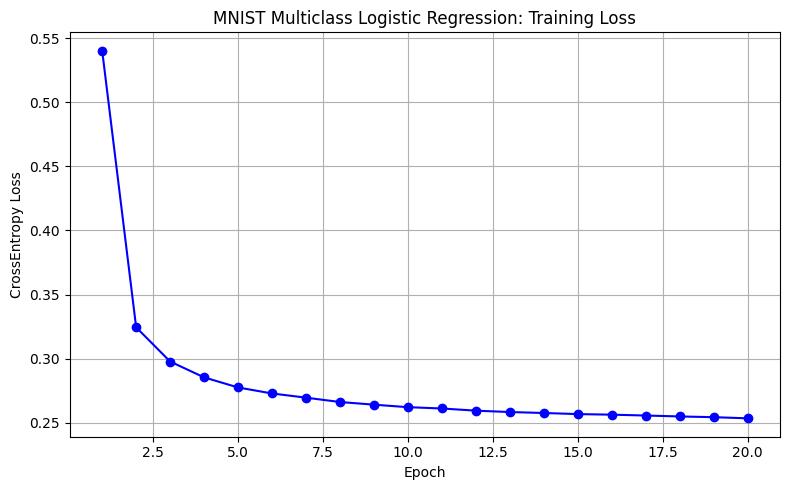


Saved model weights to outputs/mnist_logistic_model.pth


In [5]:
train_losses = []

print("Starting Training...")
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    avg_loss = running_loss / len(train_ds)
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch+1:02d}/{EPOCHS}] Loss: {avg_loss:.4f}")

# Plot Training Loss
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, marker="o", color="blue")
plt.title("MNIST Multiclass Logistic Regression: Training Loss")
plt.xlabel("Epoch")
plt.ylabel("CrossEntropy Loss")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/training_loss.png", dpi=150)
plt.show()

# Save Model Parameters
torch.save(model.state_dict(), "outputs/mnist_logistic_model.pth")
print("\nSaved model weights to outputs/mnist_logistic_model.pth")

Evaluate Model, Confusion Matrix & Predictions

Test Accuracy: 92.68%
Baseline Accuracy (Most Frequent): 11.35%

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       980
           1       0.96      0.98      0.97      1135
           2       0.92      0.91      0.92      1032
           3       0.91      0.91      0.91      1010
           4       0.94      0.93      0.93       982
           5       0.91      0.88      0.89       892
           6       0.93      0.96      0.94       958
           7       0.93      0.92      0.93      1028
           8       0.89      0.89      0.89       974
           9       0.90      0.91      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



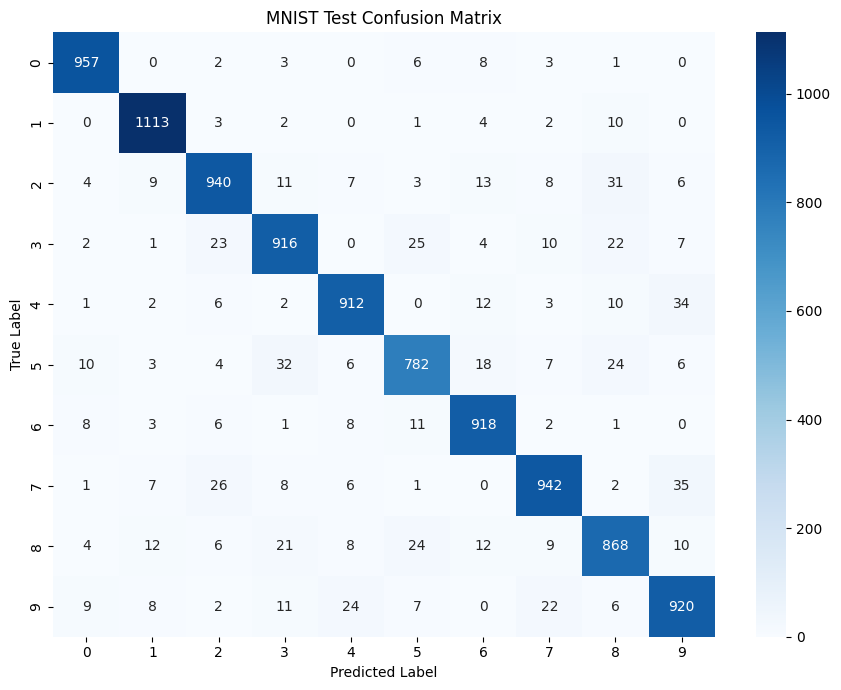

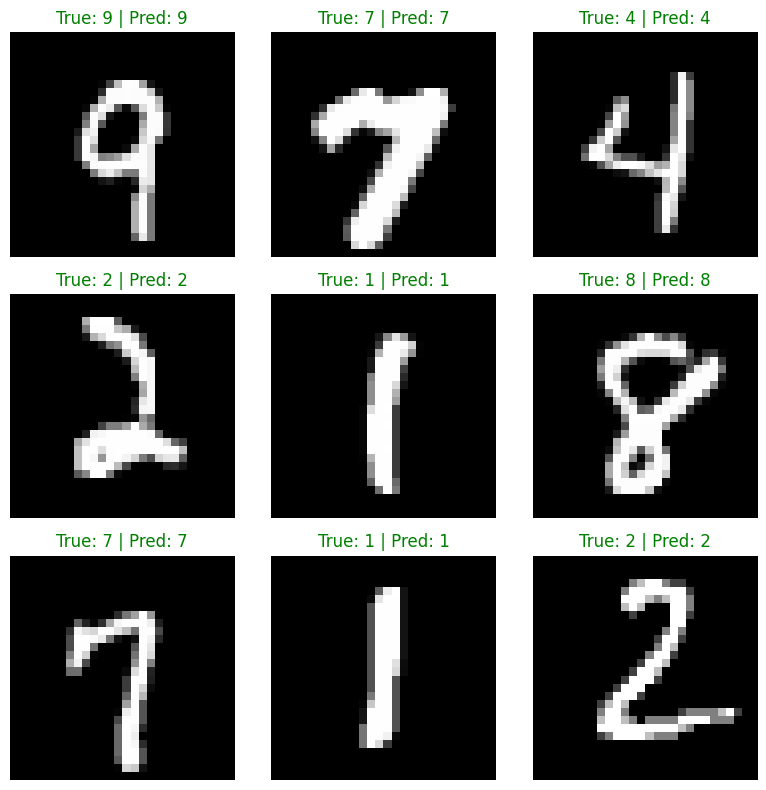

In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.dummy import DummyClassifier

model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Test Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {acc:.2%}")

# Baseline Accuracy
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"Baseline Accuracy (Most Frequent): {baseline_acc:.2%}\n")

# Print Classification Report
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("MNIST Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("outputs/confusion_matrix.png", dpi=150)
plt.show()

# Sample Predictions Display
rng = np.random.default_rng(42)
indices = rng.choice(len(X_test), size=9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(8, 8))

for ax, idx in zip(axes.flat, indices):
    true_label = y_true[idx]
    pred_label = y_pred[idx]
    ax.imshow(X_test[idx].reshape(28, 28), cmap="gray")
    ax.set_title(f"True: {true_label} | Pred: {pred_label}", color="green" if true_label == pred_label else "red")
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/predictions.png", dpi=150)
plt.show()

Standalone Inference Test (predict.py logic)

In [7]:
# Load saved model weights into fresh model instance
loaded_model = MNISTLogisticRegression(784, 10)
loaded_model.load_state_dict(torch.load("outputs/mnist_logistic_model.pth"))
loaded_model.eval()

# Select test sample index 42
sample_idx = 42
sample_tensor = torch.tensor(X_test[sample_idx], dtype=torch.float32).unsqueeze(0)

with torch.no_grad():
    logits = loaded_model(sample_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_label = probabilities.argmax(dim=1).item()

print(f"Sample Index    : {sample_idx}")
print(f"Actual Digit    : {y_test.iloc[sample_idx]}")
print(f"Predicted Digit : {predicted_label}")
print(f"Model Confidence: {probabilities[0][predicted_label].item():.2%}")

Sample Index    : 42
Actual Digit    : 4
Predicted Digit : 4
Model Confidence: 86.33%
